In [129]:
from compecon.demos import np, plt, demo
from numpy.linalg import norm, cond, solve

In [170]:
""" Ill-conditioning of Vandermonde matrix"""
#todo: Review this demo, result not the same as in Miranda's
#fixme: There seems to be a problem with the computation of eigenvalues by numpy.linalg

# Compute approximation error and matrix condition number
n = np.arange(6, 100).astype(float)
nn = n.size

errv = np.zeros(nn)
conv = np.zeros(nn)

for i in range(nn):
    v = np.vander(1 + np.arange(n[i]))
    errv[i] = norm(np.identity(v.shape[0]) - solve(v, v))
    conv[i] = cond(v)

b =  [-25.9167   1.7687]
b =  [-13.7852   2.1752]


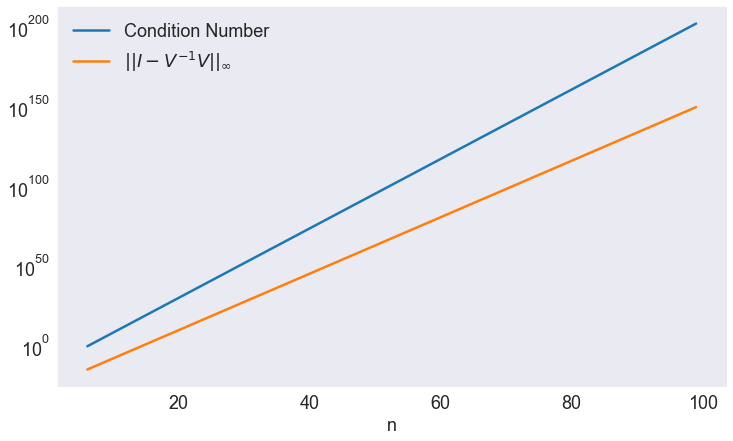

In [175]:
# Smooth using quadratic function
X = np.vstack([np.ones(nn), n]).T
b = np.linalg.lstsq(X, np.log10(errv))[0]
print('b = ', b)
errv = 10 ** np.dot(X, b)
b = np.linalg.lstsq(X, np.log10(conv))[0]
print('b = ', b)
conv = 10 ** np.dot(X, b)

# Plot matrix condition numbers
fig, ax = plt.subplots(figsize=[12, 7])

ax.plot(n, conv, label='Condition Number')
ax.plot(n,errv, label= '$||I - V^{-1}V||_\infty$')
ax.set_xlabel('n')
ax.set_yscale('log')
ax.set_yticks(10.0 ** np.array([0,50,100,150,200]))
ax.legend()
#demo.savefig([fig])

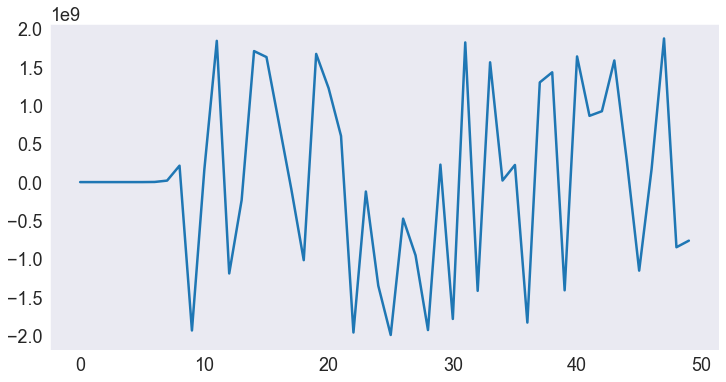

In [118]:
plt.plot(11 ** np.arange(50, dtype='long'))